In [2]:
import os
import shutil

base_dir = "Medical_Imaging_Portfolio"
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

folders = [
    "Task_1_Chest_XRay/data", "Task_1_Chest_XRay/output",
    "Task_2_Cardiac_Fusion/data", "Task_2_Cardiac_Fusion/output",
    "Task_3_Echo_Analysis/data", "Task_3_Echo_Analysis/output"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Directory structure created successfully.")

Directory structure created successfully.


Task 1 - Diagnostic Enhancement of Chest X-Ray

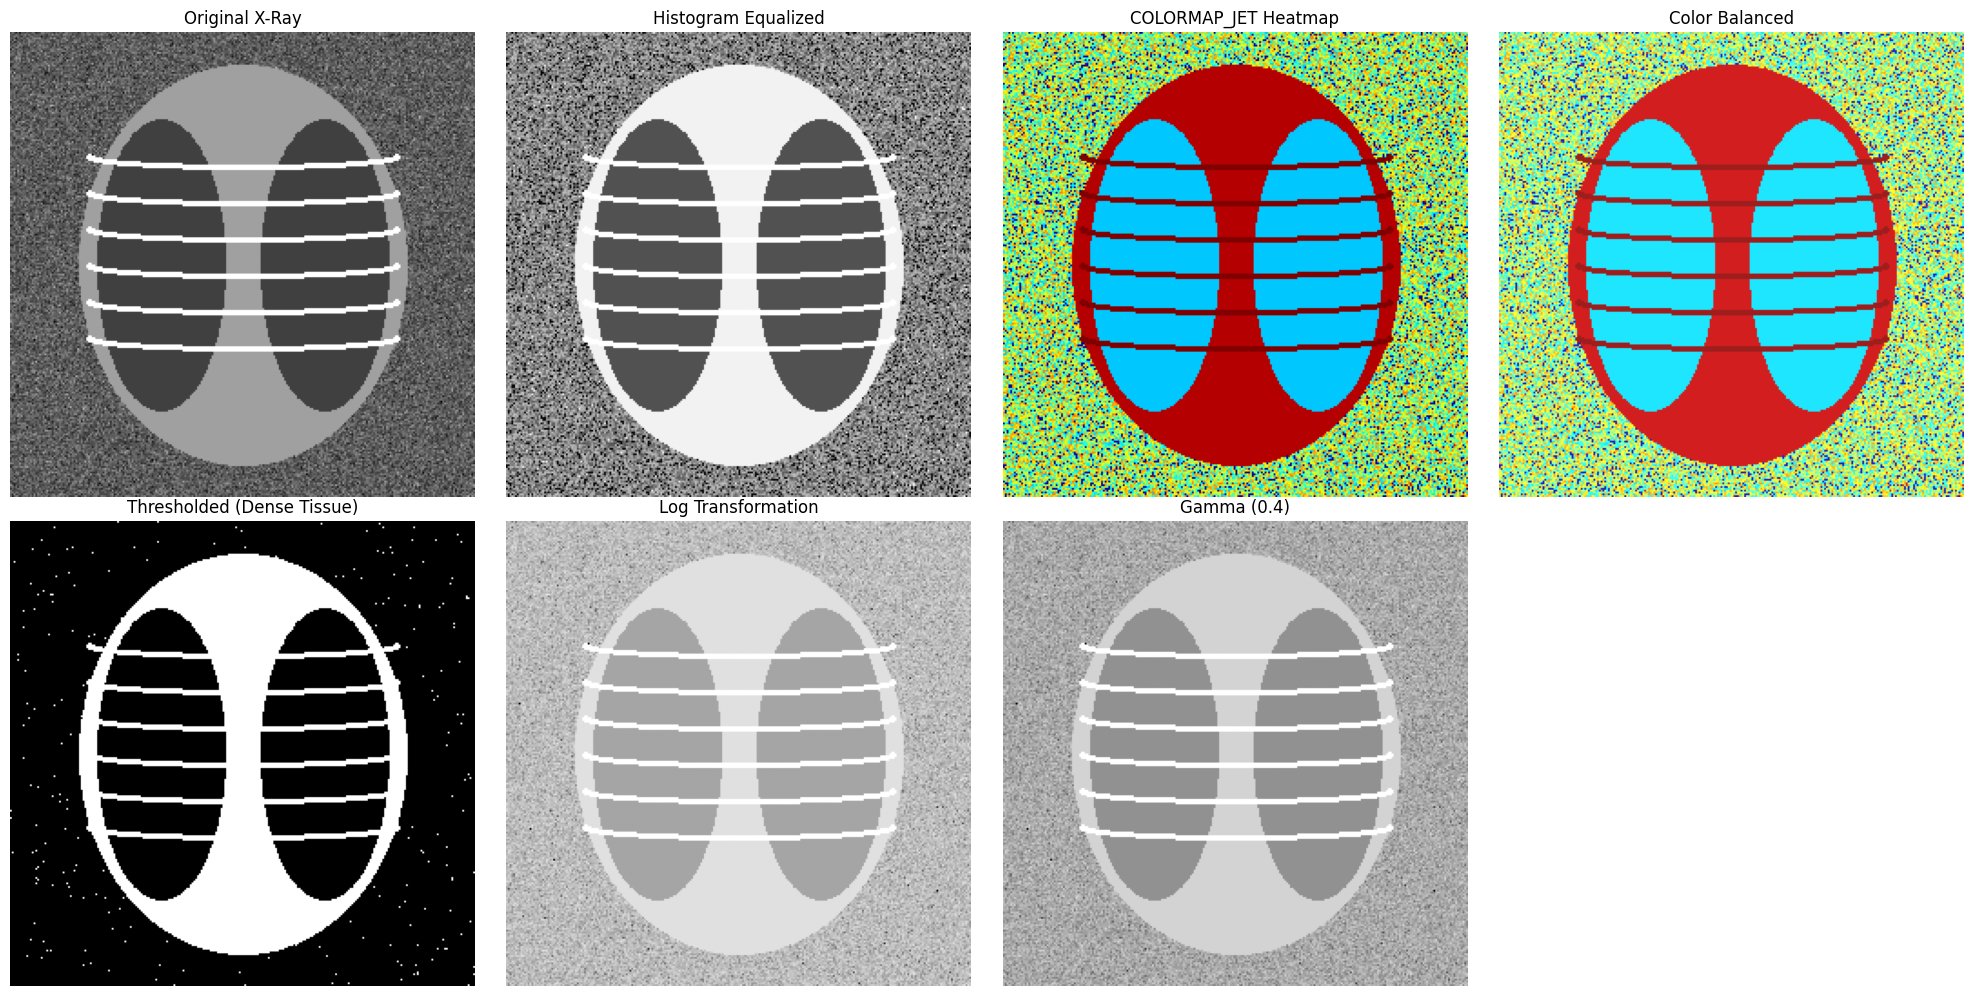

Task 1 completed. Output saved.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def load_image(path, fallback_shape=(500, 500)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"File {path} not found. Using synthetic placeholder.")
        img = np.random.randint(0, 100, fallback_shape, dtype=np.uint8)
    return img

img_xray = load_image('Medical_Imaging_Portfolio/Task_1_Chest_XRay/data/xray.png')

eq_xray = cv2.equalizeHist(img_xray)
heatmap = cv2.applyColorMap(eq_xray, cv2.COLORMAP_JET)

balanced = cv2.convertScaleAbs(heatmap, alpha=1.0, beta=30)

_, thresh = cv2.threshold(eq_xray, 200, 255, cv2.THRESH_BINARY)

log_img = np.log1p(img_xray.astype(np.float32))
log_img = cv2.normalize(log_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

gamma = 0.4
gamma_img = np.power(img_xray / 255.0, gamma)
gamma_img = np.uint8(gamma_img * 255)

plt.figure(figsize=(20, 10))
titles = ['Original X-Ray', 'Histogram Equalized', 'COLORMAP_JET Heatmap',
          'Color Balanced', 'Thresholded (Dense Tissue)', 'Log Transformation', 'Gamma (0.4)']
images = [img_xray, eq_xray, heatmap, balanced, thresh, log_img, gamma_img]

for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    if len(images[i].shape) == 3:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('Medical_Imaging_Portfolio/Task_1_Chest_XRay/output/enhanced_xray.png', heatmap)
print("Task 1 completed. Output saved.")

Task 2 - Multi-Modal Cardiac Image Fusion

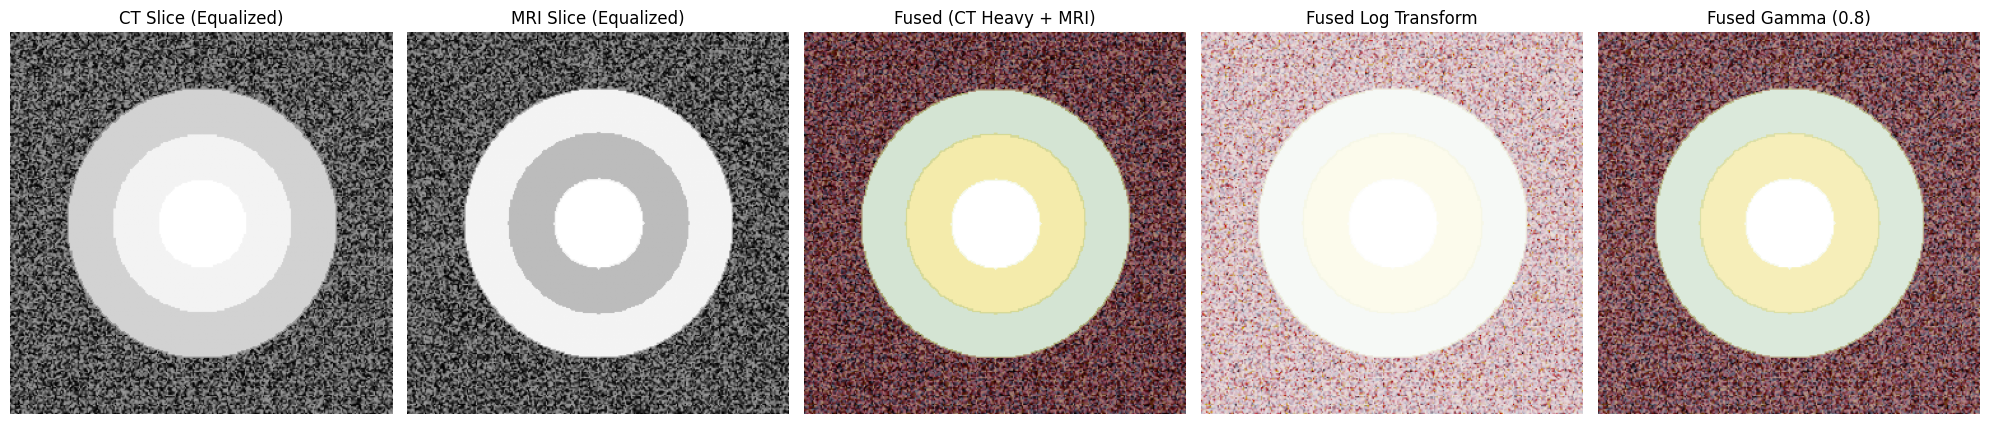

Task 2 completed. Output saved.


In [4]:
def load_and_resize(path, size=(300, 300)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"File {path} not found. Using synthetic placeholder.")
        img = np.random.randint(0, 255, size, dtype=np.uint8)
    return cv2.resize(img, size)

ct_img = load_and_resize('Medical_Imaging_Portfolio/Task_2_Cardiac_Fusion/data/ct.png')
mri_img = load_and_resize('Medical_Imaging_Portfolio/Task_2_Cardiac_Fusion/data/mri.png')

ct_eq = cv2.equalizeHist(ct_img)
mri_eq = cv2.equalizeHist(mri_img)

ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_HOT)

alpha = 0.7
beta = 0.3
fused = cv2.addWeighted(ct_color, alpha, mri_color, beta, 0)

log_fused = np.log1p(fused.astype(np.float32))
log_fused = cv2.normalize(log_fused, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

gamma = 0.8
gamma_fused = np.power(fused / 255.0, gamma)
gamma_fused = np.uint8(gamma_fused * 255)

plt.figure(figsize=(20, 6))
titles = ['CT Slice (Equalized)', 'MRI Slice (Equalized)', 'Fused (CT Heavy + MRI)', 'Fused Log Transform', 'Fused Gamma (0.8)']
images = [ct_eq, mri_eq, fused, log_fused, gamma_fused]

for i in range(len(images)):
    plt.subplot(1, 5, i+1)
    if len(images[i].shape) == 3:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('Medical_Imaging_Portfolio/Task_2_Cardiac_Fusion/output/fused_heart.png', fused)
print("Task 2 completed. Output saved.")

Task 3 - Real-Time Echocardiogram Video Analysis

In [5]:
import cv2
import numpy as np
from IPython.display import Video, display

input_path = 'Medical_Imaging_Portfolio/Task_3_Echo_Analysis/data/echo.mp4'
output_path = 'Medical_Imaging_Portfolio/Task_3_Echo_Analysis/output/enhanced_echo.mp4'

cap = cv2.VideoCapture(input_path)

if not cap.isOpened():
    print(f"Error: Could not open video {input_path}. Make sure you uploaded a .mp4 file.")
else:
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width * 2, frame_height))

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        eq = cv2.equalizeHist(gray)
        heatmap = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
        balanced = cv2.convertScaleAbs(heatmap, alpha=1.0, beta=20)

        log_img = np.log1p(eq.astype(np.float32))
        log_img = cv2.normalize(log_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        gamma = 0.6
        gamma_img = np.power(eq / 255.0, gamma)
        gamma_img = np.uint8(gamma_img * 255)

        enhanced = cv2.applyColorMap(gamma_img, cv2.COLORMAP_JET)

        combined = np.hstack((frame, enhanced))
        out.write(combined)

        frame_count += 1
        if frame_count > 100:
            break

    cap.release()
    out.release()
    print(f"Task 3 completed. Processed {frame_count} frames. Video saved to {output_path}")
    display(Video(output_path, embed=True))

Task 3 completed. Processed 60 frames. Video saved to Medical_Imaging_Portfolio/Task_3_Echo_Analysis/output/enhanced_echo.mp4


In [6]:
base_dir = "Medical_Imaging_Portfolio"

with open(os.path.join(base_dir, "requirements.txt"), "w") as f:
    f.write("opencv-python==4.8.0\nnumpy==1.26.0\nmatplotlib==3.7.1\n")

readme_content = """# StudentName_Medical_Imaging_Portfolio

## Task 1: Chest X-Ray Enhancement
Pipeline: Load grayscale -> Histogram Equalization -> COLORMAP_JET -> Color Balance -> Thresholding -> Log Transform -> Gamma (0.4).
Purpose: Maximize structural visibility of lung cavities and fluid build-up.

## Task 2: Cardiac Image Fusion
Pipeline: Load CT & MRI -> Equalize -> Color Map -> cv2.addWeighted (0.7 CT, 0.3 MRI) -> Log & Gamma Transforms.
Purpose: Combine CT structural boundaries with MRI soft tissue variations.

## Task 3: Echocardiogram Video Analysis
Pipeline: Frame-by-frame processing -> Equalization -> COLORMAP_JET -> Color Balance -> Log -> Gamma (0.6).
Output: Side-by-side video of raw vs. enhanced ultrasound.
"""

with open(os.path.join(base_dir, "README.md"), "w") as f:
    f.write(readme_content)

print("Files created successfully. You can now download the 'Medical_Imaging_Portfolio' folder from the Colab sidebar and submit it.")

Files created successfully. You can now download the 'Medical_Imaging_Portfolio' folder from the Colab sidebar and submit it.
